# Project 11 -- Anthony Micco

**TA Help:** None

**Collaboration:** None

**Internet Resources:** 
- https://en.wikipedia.org/wiki/Linear_interpolation (Utilized to understand how linear interpolation works)
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html (Used to understand how the forward fill function works)
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.bfill.html (Used to understand how the backward fill function works)
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mode.html (Used to understand how to use mode function)
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.median.html (used to understand how to use median function)
- https://stackoverflow.com/questions/10998621/rotate-axis-tick-labels (Used to rotate x-label ticks on censored vs observed plot labels)
- https://lifelines.readthedocs.io/en/latest/fitters/regression/CoxPHFitter.html (Used to understand the Cox Regression Model)

**ChatGPT, Gemini, Claude, etc:** None

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [52]:
# loading in the data and viewing the first 5 rows
import pandas as pd
survival_data = pd.read_csv('/anvil/projects/tdm/data/survival/SurvivalData.csv')

In [53]:
survival_data.head()

,Unnamed: 0,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,1,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN
1,2,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
2,3,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0
3,4,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
4,5,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0


In [54]:
survival_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  228 non-null    int64  
 1   inst        227 non-null    float64
 2   time        228 non-null    int64  
 3   status      228 non-null    int64  
 4   age         228 non-null    int64  
 5   sex         228 non-null    int64  
 6   ph.ecog     227 non-null    float64
 7   ph.karno    227 non-null    float64
 8   pat.karno   225 non-null    float64
 9   meal.cal    181 non-null    float64
 10  wt.loss     214 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 19.7 KB


In [55]:
#recoding the status variable

#setting death status equal to 1 
survival_data["status"] = survival_data['status'].replace({1: 0, 2: 1})

In [56]:
#filling in any missing or NaN values

#using linear interpolation on meal.cal and wt.loss columns to fill missing values
survival_data[["meal.cal","wt.loss"]] = survival_data[["meal.cal","wt.loss"]].interpolate(method='linear')

In [57]:
#using forward and backward fill to remove NaN values
survival_data[["meal.cal","wt.loss"]] = survival_data[["meal.cal","wt.loss"]].ffill().bfill()

In [58]:
#filling in inst using mode
survival_data["inst"] = survival_data["inst"].fillna(survival_data["inst"].mode()[0])

In [59]:
#filling in the missing values for the remaining columns with their medians
survival_data[['ph.ecog','ph.karno','pat.karno']] = survival_data[['ph.ecog','ph.karno','pat.karno']].fillna(survival_data[['ph.ecog','ph.karno','pat.karno']].median(numeric_only=True))

In [60]:
survival_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  228 non-null    int64  
 1   inst        228 non-null    float64
 2   time        228 non-null    int64  
 3   status      228 non-null    int64  
 4   age         228 non-null    int64  
 5   sex         228 non-null    int64  
 6   ph.ecog     228 non-null    float64
 7   ph.karno    228 non-null    float64
 8   pat.karno   228 non-null    float64
 9   meal.cal    228 non-null    float64
 10  wt.loss     228 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 19.7 KB


## Question 2

In [61]:
#printing how many status values are 0 and 1
survival_data["status"].value_counts()

status
1    165
0     63
Name: count, dtype: int64

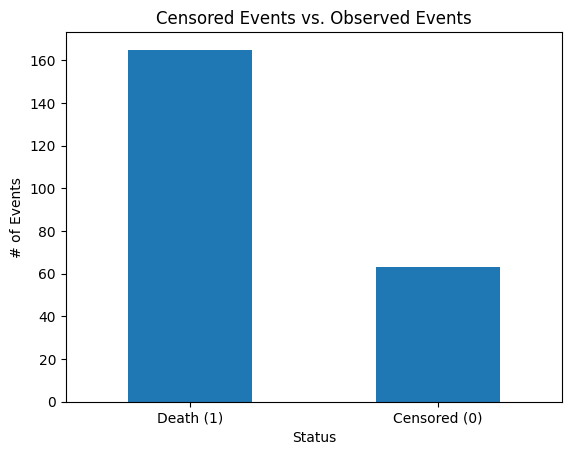

In [62]:
#plotting the proportion of censored events versus observed events
import matplotlib.pyplot as plt
survival_data['status'].value_counts().plot(kind='bar')
plt.xticks([1,0], ['Censored (0)', 'Death (1)'], rotation=0)
plt.ylabel('# of Events')
plt.xlabel('Status')
plt.title('Censored Events vs. Observed Events')
plt.show()

In [63]:
#creating a scatterplot showing patient's follow-up time and patient index

#sorting by time
df_sorted = survival_data.sort_values(by='time')

#making death events red and censored events blue
colors = df_sorted['status'].map({1.0: 'red', 0.0:'blue'})

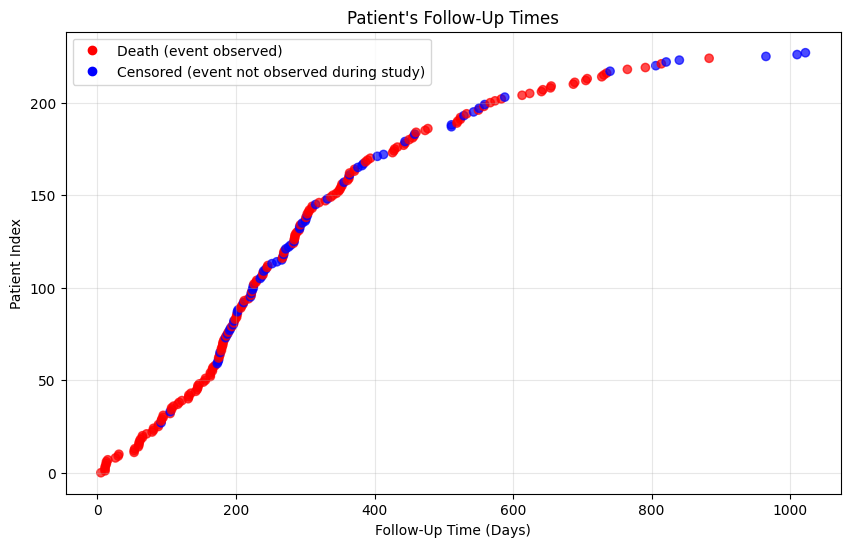

In [64]:
#plotting figure and creating a legend for it
plt.figure(figsize=(10, 6))
plt.scatter(
    df_sorted['time'],
    range(len(df_sorted)),
    c=colors,
    alpha=0.7
)

plt.title("Patient's Follow-Up Times") 
plt.xlabel("Follow-Up Time (Days)")
plt.ylabel("Patient Index") 

# Custom legend
plt.legend(handles=[
    plt.Line2D([], [], marker='o', color='red', linestyle='None',
               label='Death (event observed)'),
    plt.Line2D([], [], marker='o', color='blue', linestyle='None',
               label='Censored (event not observed during study)')
])

plt.grid(alpha=0.3)
plt.show()

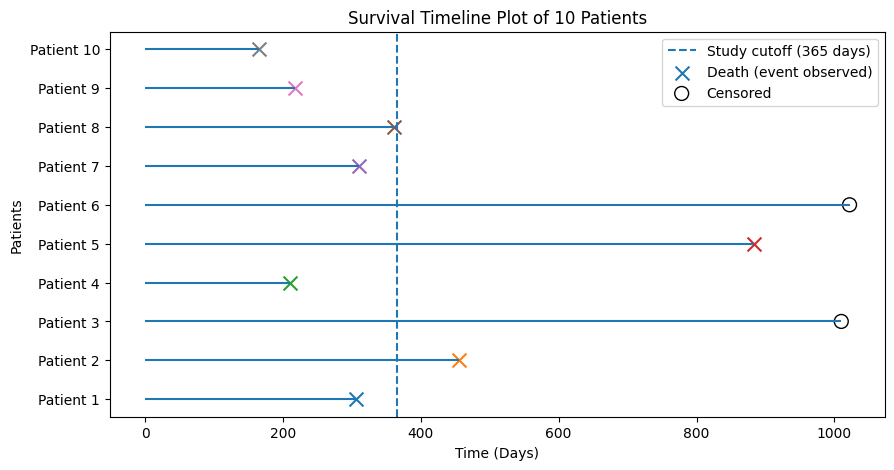

In [65]:
#plotting a survival timeline plot for the first 10 patients
import matplotlib.pyplot as plt

# Select the first 10 patients from the dataset
plot_df = survival_data.head(10).reset_index(drop=True)

# Create plot
plt.figure(figsize=(10, 5))
plt.axvline(x=365, linestyle='--', label='Study cutoff (365 days)')

death_labeled = False
censor_labeled = False

# Plot each patient's survival timeline
for i, row in plot_df.iterrows():
    plt.hlines(y=i+1, xmin=0, xmax=row['time'])

    if row['status'] == 1:
        plt.scatter(
            row['time'], i+1,
            marker='x', s=100,
            label='Death (event observed)' if not death_labeled else None
        )
        death_labeled = True
    else:
        plt.scatter(
            row['time'], i+1,
            facecolors='none', edgecolors='black', s=100,
            label='Censored' if not censor_labeled else None
        )
        censor_labeled = True

plt.yticks(range(1, 11), [f'Patient {i}' for i in range(1, 11)])
plt.xlabel('Time (Days)')
plt.ylabel('Patients')
plt.title('Survival Timeline Plot of 10 Patients')
plt.legend()
plt.show()

2b) I think it is interesting that there is a significant overlap in the oberseved events and censored events between the 200 and 400 days follow-up times. I could infer that these studies required a yearly follow-up so most of these patients follow-up or passed away within this time-frame. 

2c) From the survival timeline plot, I notice that 60 percent $(\frac{6}{10})$ of the patients were observed deaths within the 365 day timeframe, while 2 patients passed away after the 365 day timeframe. The last two patients were censored and an event was not recorded within the timeframe.

## Question 3

In [66]:
#finding the first two event times in the survival_dataset

#identifying all event times in the dataset
event_times = (
    survival_data
    .loc[survival_data["status"] == 1, "time"]
    .sort_values()
    .unique()
)

#printing the first two
event_times[:2]

array([ 5, 11])

In [67]:
#finding the survival probability for S(5)
# First event time
t1 = event_times[0]

# Count patients at risk and deaths
n1 = (survival_data["time"] >= t1).sum()
d1 = ((survival_data["time"] == t1) & (survival_data["status"] == 1)).sum()

# Kaplan Meier Equation
S1 = 1 * (1- (d1/n1)) 

print("Time =", t1)
print("At risk n1 =", n1)
print("Deaths d1 =", d1)
print("S(t1) =", S1)

Time = 5
At risk n1 = 228
Deaths d1 = 1
S(t1) = 0.9956140350877193


In [68]:
#finding the survival probability for S(11)
# Second event time
t2 = event_times[1]

# Count patients at risk and deaths
n2 = (survival_data["time"] >= t2).sum()
d2 = ((survival_data["time"] == t2) & (survival_data["status"] == 1)).sum()

# Update survival probability
S2 = S1 * (1- (d2/n2))

print("Time =", t2)
print("At risk n2 =", n2)
print("Deaths d2 =", d2)
print("S(t2) =", S2)

Time = 11
At risk n2 = 227
Deaths d2 = 3
S(t2) = 0.9824561403508771


3a) The survival function S(t) represents the probability of a patient surviving at or before day t. Essentially, it says that S(t) percent of patients are expected to survive past day t.  

3b) S(5) in this study suggests that approximately 99.56% of patients are expected to survive past day 5. 

3c) S(11) in this study suggests that approximately 98.25% of patients are expected to survive past day 11.

## Question 4

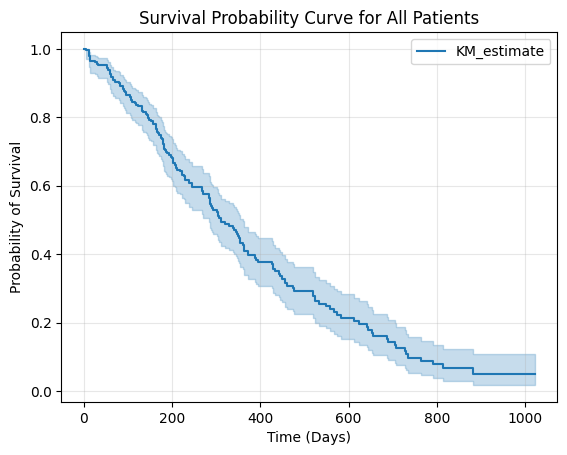

In [69]:
#fitting a Kaplan-Meier survival probability curve for all patients
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_data["time"],
    event_observed=(survival_data["status"] == 1)
)

kmf.plot(ci_show=True)
plt.xlabel("Time (Days)") 
plt.ylabel("Probability of Survival")
plt.title("Survival Probability Curve for All Patients")
plt.grid(alpha=0.3)
plt.show()

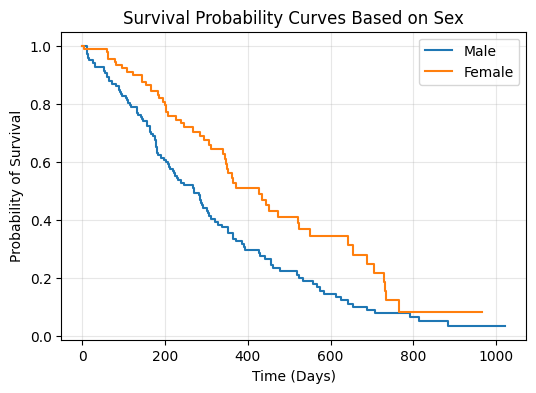

In [70]:
#plotting a Kaplan-Meier survival probability curve separated by gender
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(6, 4))

for sex_value, label in [(1, "Male"), (2, "Female")]:
    group = survival_data[survival_data["sex"] == sex_value]

    if group.empty:
        continue

    kmf.fit(
        durations=group["time"],
        event_observed=(group["status"] == 1),
        label=label
    )
    kmf.plot(ci_show=False)

plt.xlabel("Time (Days)") 
plt.ylabel("Probability of Survival")
plt.title("Survival Probability Curves Based on Sex")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [71]:
#using a log-rank test to compare survival between sexes
from lifelines.statistics import logrank_test

# Separate data by sex
male = survival_data[survival_data["sex"] == 1]
female = survival_data[survival_data["sex"] == 2]

# Run log rank test
results = logrank_test(
    male["time"],
    female["time"],
    event_observed_A=(male["status"] == 1),
    event_observed_B=(female["status"] == 1)
)

# Print results
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          10.33 <0.005      9.57

4a) Based on the Kaplan-Meier Survival Probability curve of all the patients together, it suggests that as the days increase, the probability of survival decreases and it becomes less likely a patient survives past day t. 

4b) From the Kaplan-Meier survival probability curve separated by sex, I noticed that female survival probability decreases much slower than male survival probability and there are longer plateaus where the probability does not change for x amount of days. This difference does create a gap between the two probabilities until about day 775 when they begin to meet and have similar survival probabilities.  

4c) Based on the log-rank test we peformed on the data, we can say that there is evidence that there are differing log hazards between male and female patients because the p-value is less than 0.05. Since the p-value is very small, it is statistically significant, thus indicating that sex impacts the survival probability. 

## Question 5

In [75]:
# fitting a Cox Regression Model and Viewing the results
from lifelines import CoxPHFitter

# Prepare modeling dataset
cox_data = survival_data[['time', 'status', 'age', 'sex',
                           'ph.ecog', 'ph.karno',
                           'pat.karno', 'meal.cal', 'wt.loss']]
# Fit Cox model
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='time', event_col='status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 228 total observations, 63 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 228
number of events observed = 165
   partial log-likelihood = -731.93
         time fit was run = 2026-04-10 17:50:33 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
sex       -0.58      0.56      0.17           -0.92           -0.25                0.40                0.78
ph.ecog    0.57      1.77      0.18            0.21            0.93                1.23                2.53
ph.karno   0.01      1.01      0.01           -0.01            0.03                0.99                1.03
pat.karno -0.01      0.99      0.01           -0.03            0.00                0.98                1.00
meal.cal   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
wt.loss   -0.01      0.99      0.01           -0.02            0.00                0.98                1.00

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  1.31   0.19      2.40
sex          0.00 -3.42 <0.005     10.64
ph.ecog      0.00  3.11 <0.005      9.08
ph.karno     0.00  1.43   0.15      2.70
pat.karno    0.00 -1.66   0.10      3.38
meal.cal     0.00  0.14   0.89      0.17
wt.loss      0.00 -1.24   0.22      2.21
---
Concordance = 0.65
Partial AIC = 1477.86
log-likelihood ratio test = 35.96 on 7 df
-log2(p) of ll-ratio test = 17.05

In [77]:
#creating a table to summarize Cox regression results
import pandas as pd
import numpy as np

# Extract coefficients and p-values
hr_table = cph.summary[['coef', 'p']].reset_index()
hr_table.columns = ['Predictor', 'Log_Hazard_Ratio (coef)', 'p_value']

# Compute hazard ratio from the log hazard coefficient
hr_table['Hazard_Ratio (HR)'] = np.exp(hr_table['Log_Hazard_Ratio (coef)']) # For YOU to fill in


# Using the table above, fill in the Effect column:
# * If the hazard ratio is greater than 1, fill in whether it increases or decreases hazard.
 #* If the hazard ratio is less than 1, fill in whether it increases or decreases hazard.

hr_table['Effect'] = np.where(
    hr_table['Hazard_Ratio (HR)'] >= 1,
    'Increases', 
    'Decreases' 
)

# Round values for display
hr_table[['Log_Hazard_Ratio (coef)',
          'Hazard_Ratio (HR)',
          'p_value']] = (
    hr_table[['Log_Hazard_Ratio (coef)',
              'Hazard_Ratio (HR)',
              'p_value']]
    .round(3)
)

hr_table

,Predictor,Log_Hazard_Ratio (coef),p_value,Hazard_Ratio (HR),Effect
0,age,0.012,0.190,1.012,Increases
1,sex,-0.582,0.001,0.559,Decreases
2,ph.ecog,0.570,0.002,1.767,Increases
3,ph.karno,0.013,0.154,1.014,Increases
4,pat.karno,-0.011,0.096,0.989,Decreases
5,meal.cal,0.000,0.888,1.000,Increases
6,wt.loss,-0.008,0.217,0.992,Decreases


5c) From the table in 5b, we can say that based on the p-values, only the sex and ph.ecog predictors are statistically significant since their p-values are 0.001 and 0.002 respectively and less than 0.05. The sex predictor decreases the patient hazard by approximately 44% based on the sex, and judging by the Kaplan-Meier curve from the previous question, females have a 44% less impacted than men. In addition, the ph.ecog produces an approximately 77% increase in patient hazard for every one unit increase in ECOG. These suggest that females and people with lower ECOG values have a better chance of survival than men and people with higher ECOG values. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
